In [1]:
import pandas as pd
import numpy as np
groups = [
    "NCD", "BL", "NAD", "AI", "NAC", "ND",
    "CS", "AT", "NA", "ADL", "AS_NA", "AS_NAC"
]

columns = [f"{group}_{t}" for group in groups for t in range(8)]
columns.append("target")

df = pd.read_csv(
    "TomsHardware.data",
    header=None,
    names=columns
)

df["target_log"] = np.log1p(df["target"])
print(df.shape)
#df.head(20)

(28179, 98)


In [2]:
top_groups = ['AS_NA', 'ADL', 'NAD', 'AS_NAC', 'CS']

print("Top groups:", top_groups)

selected_columns = [
    col for col in df.columns
    if any(col.startswith(group + "_") for group in top_groups)
]

df_top_features = df[selected_columns + ["target", "target_log"]].copy()

print(df_top_features.shape)
df_top_features.head()

Top groups: ['AS_NA', 'ADL', 'NAD', 'AS_NAC', 'CS']
(28179, 42)


,NAD_0,NAD_1,NAD_2,NAD_3,NAD_4,NAD_5,NAD_6,NAD_7,CS_0,CS_1,...,AS_NAC_0,AS_NAC_1,AS_NAC_2,AS_NAC_3,AS_NAC_4,AS_NAC_5,AS_NAC_6,AS_NAC_7,target,target_log
0,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.5,1.704748
1,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.5,1.504077
2,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.098612
3,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.098612
4,0,0,0,0,0,0,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.5,0.916291


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor


X = df_top_features.drop(columns=["target", "target_log"])
y = df_top_features["target_log"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


estimators = [
    ("rf", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )),
    ("extra", ExtraTreesRegressor(
        n_estimators=150,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )),
    ("xgb", XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )),
    ("cat", CatBoostRegressor(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        verbose=0
    ))
]


stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=3,
    n_jobs=1,
    passthrough=False
)


stacking_model.fit(X_train, y_train)


y_pred_log = stacking_model.predict(X_test)


mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = mean_squared_error(y_test, y_pred_log) ** 0.5
r2_log = r2_score(y_test, y_pred_log)

print("Stacking Ensemble Regression on log(target) - top feature groups")
print(f"MAE  (log scale): {mae_log:.4f}")
print(f"RMSE (log scale): {rmse_log:.4f}")
print(f"R²   (log scale): {r2_log:.4f}")

Stacking Ensemble Regression on log(target) - top feature groups
MAE  (log scale): 0.8205
RMSE (log scale): 1.1388
R²   (log scale): 0.7698


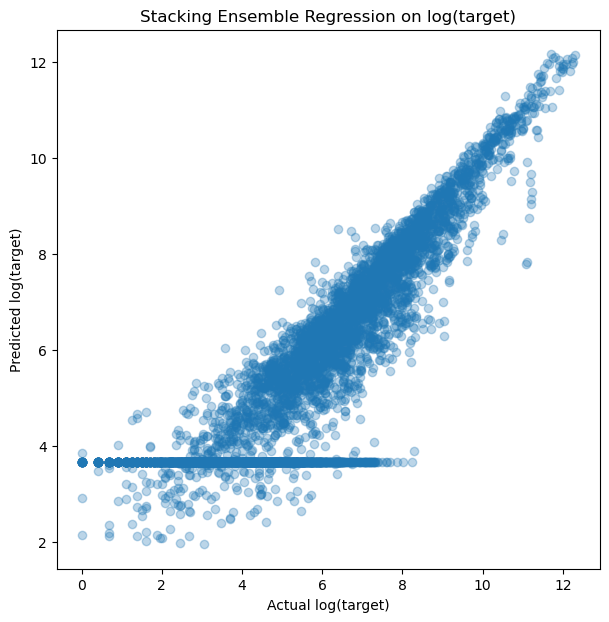

In [4]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_log, alpha=0.3)
plt.xlabel("Actual log(target)")
plt.ylabel("Predicted log(target)")
plt.title("Stacking Ensemble Regression on log(target)")
plt.show()